# A Basic Overview

dLux is a differentiable physical optical modelling framework built within the [Jax](https://github.com/jax-ml/jax)+[Equinox](https://github.com/patrick-kidger/equinox)+[Zodiax](https://github.com/LouisDesdoigts/zodiax) ecosystem, providing differentiability, GPU acceleration, a friendly object-oriented API, as well as a series of optimisation and inference tools and utilities designed for scientific programming. It is designed to be incredibly fast, flexible, and extensible, serving as framework to solve real-world optical problems within, rather than just another optical simulator. It was built for the modelling of astronomical telescopes, but the tools it provides and its flexible construction make it applicable to optical problems well beyond this domain.

Under the hood, dLux takes inspiration from the isomorphic nature between optical system and neural networks, enabling the description of arbitrary optical systems as a series of layers that operate sequentially on a wavefront. This 'layers based' design provides near-complete flexibility to end users (since you can easily define your own layer!), while also enabling most optical systems to be composed from layers that are already implemented within dLux. Unlike other optical simulators, dLux aims to put tools in users hands and teach them how to use them, not provide a pre-built system that works in unknown ways with unknown side-effects! This formulation provides far more power than traditional optical simulators, but also requires a bit more work to get up and running. 

This tutorial is designed to give users a basic introduction to the core parts of dLux. We will cover how to create an optical system and its psf, how to work with dLux objects, and show a basic optimisation workflow. It will be broken down into the following sections:

1. Building an Optical System
2. Simulating Data
3. A Basic Optimisation Workflow
4. Instrumental Calibration

In [1]:
## COLLAPSE: Imports
# Basic imports
import jax.numpy as np
import jax.random as jr

# Optimisation imports
import equinox as eqx
import zodiax as zdx
import optax

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import CenteredNorm

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 90

# Nan friendly colormapping
inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

---

## 1. Building an Optical System

Lets start by taking a look at how to build an optical system in dLux, we will focus on the `AngularOpticalSystem` class as it is the most-common for astronomical problems. As mentioned above, dLux optical systems are built from a series of layers that operate sequentially on a wavefront. Each layer is designed to represent a specific transformation to the wavefront, such as encountering an aperture, phase aberration, or propagating to focus. By combining these layers together, we can build up complex optical systems that can model real-world telescopes and instruments.

Beyond the layers themselves, we also need to define a few other properties of the optical system. In order to construct at wavefront at the aperture of the telescope we need to define its diameter, and the number of pixels used to represent the wavefront. To propagate the wavefront to the focal plane, we also need to define the pixel scale of the PSF, and the number of pixels used to represent the PSF.

For this problem, we will build a Euclid-like optical system, since the asymmetry of its aperture makes recovering even Zernike modes easy! Rather than looking at how to build this aperture from scratch here (since we have tutorials on that [here](https://louisdesdoigts.github.io/dLux/tutorials/howtos/custom_apertures/)), we will use a helper function that constructs the aperture for us, imported from the local `optics.py` file. Using this optical system we will model an PSF with optical aberrations and show how we can recover these aberrations directly. 

Lets look at how to build this optical system, starting by getting the different pieces we need together

In [2]:
# Define our wavefront properties
wf_npix = 256  # Number of pixels in the wavefront
diameter = 1.0  # Diameter of the wavefront, meters

# Define our detector properties
psf_npix = 64  # Number of pixels in the PSF
psf_pixel_scale = 50e-3  # 50 mili-arcseconds

# Generate a euclid-like aperture and Zernike
aperture, basis = dlu.euclid_like(
    npixels=wf_npix,
    diameter=1.1,
    oversample=5,  # Oversampling factor
    secondary_diameter=0.25,  # Diameter of the secondary
    spider_width=0.075,  # Width of the spiders
    zernike_nolls=np.arange(4, 22)  # Skip piston tip tilt
)

# Normalise the basis to nm and generate some random coefficients
basis *= 1e-9
coeffs = 25 * jr.normal(jr.key(0), basis.shape[0])

Now that we have the bits we need to define our optical system, lets see how we can actually construct it with our variables and layers. There are two layers we are going to need here, the `TransmissiveLayer` and the `BasisLayer`. These will be used to apply our aperture and our optical aberrations respectively. 

We define these layers using a list, ordered in the sequence in which we would like to apply them. While we can pass in the layer directly, its helpful to pass in a tuple pair of `(key, layer)`, as this lets us specify a key that we can use to reference that layer directly, giving us a nicer way to interact with our resutling `OpticalSystem` object.

In [3]:
# Define our aperture layer - note the normalise tells the optical system to normalise
# the wavefront at this layer.
aperture = dl.layers.TransmissiveLayer(transmission=aperture, normalise=True)

# Define our aberrations layer, this will apply our basis as an OPD to the wavefront
aberrations = dl.layers.BasisLayer(basis=basis, coefficients=coeffs)

# Define the optical layers
layers = [
    ("aperture", aperture),
    ("aberrations", aberrations),
]

# Construct the optics object
optics = dl.AngularOpticalSystem(
    wf_npixels=wf_npix, 
    diameter=diameter, 
    layers=layers, 
    psf_npixels=psf_npix, 
    psf_pixel_scale=psf_pixel_scale
)

# Examine the optics object
print(optics)

AngularOpticalSystem(
  wf_npixels=256,
  diameter=1.0,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[256,256], normalise=True),
    'aberrations':
    BasisLayer(basis=f32[18,256,256], coefficients=f32[18], as_phase=False)
  },
  psf_npixels=64,
  oversample=1,
  psf_pixel_scale=0.05
)


Great, as we can see, we now have an optical system object! As you can see dLux objects have pretty-printing syntax (inherited from Equinox) that gives us a nice summary of the object and its properties. This becomes very helpful to understand, manipulate, and work with our classes and highlights one of the core ethos' of dLux - transparency. We want users to understand what is going on under the hood, never do anything 'magic' or hidden, and to be able to interact with it in a way that is intuitive and easy to understand. Now lets see how we can use it!


With our optical system defined, we can now propagate a wavefront through it to get a PSF. The core function for this is the `propagate` method, letting us throw whatever wavelengths we would like through the system. Lets see what this looks like in practice.

In [4]:
# Define the spectral properties of our source for the propagation
wavels = 1e-6 * np.linspace(0.75, 1, 5)
weights = np.linspace(0.5, 1, len(wavels))
weights /= weights.sum()

# Set the position of the source on-sky
position = dlu.arcsec2rad(np.array([0.1, 0.05]))

# Propagate through the system to get the PSF
psf = optics.propagate(wavels, offset=position, weights=weights)

Now lets take a quick look at our aperture, OPD, and PSF to see what we are working with.

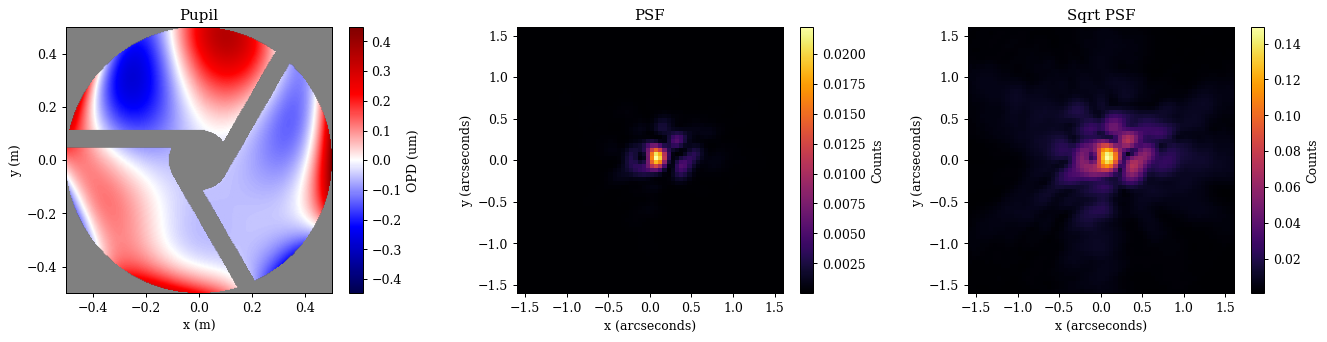

In [5]:
## COLLAPSE: Plotting
# Get the aperture and OPD for visualisation
opd = 1e6 * optics.aberrations.eval_basis()  # Normalise to microns
pupil = opd.at[optics.transmission < 0.5].set(np.nan)

# Get the extents for visualisation
ap_extent = dlu.imshow_extent(optics.diameter)
psf_extent = dlu.imshow_extent(optics.fov)

# Plot the results
plt.figure(figsize=(15, 3.75))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(pupil, seismic, norm=CenteredNorm(), extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="Pupil", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 3, 2)
im = ax.imshow(psf, inferno, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="PSF", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

ax = plt.subplot(1, 3, 3)
im = ax.imshow(psf**0.5, inferno, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Sqrt PSF", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

plt.tight_layout()
plt.show()

---

## 2. Simulating Data

Now that we have a psf, we can use it to simulate some data that we will recover the optical aberrations from. We will do this using the jax.random module to add some noise. This is important when simulating systems as otherwise our model can represent our data to machine precision and the optimisation will never really converge!

To make this a realistic simulation we need to add some flux to our PSF, as well as some read noise from the detector. Since we already normalised our optical system at the aperture layer, our PSF represents the probability distribution of one photon passing through the aperture. This means that our recovered fluxes will represent the amount of photons passing through the aperture, so we can map this to a real flux using the collecting area of the aperture. Also, since a non-zero amount of light will diffract beyond the edge of the detector, our PSF sum will always be less than zero, which is representative of the real world where we never capture all the light from a source.



In [6]:
# Generate the illuminance and define the read noise
flux = 5e5
illumination = flux * psf  # Put 1 million photons through the aperture
read_noise = 10.0  # 10 electrons of read noise

# Define the number of images we want to simulate
n_frames = 100

# Draw the photons and read noise from the appropriate distributions
shape = (n_frames, *illumination.shape)
photons = jr.poisson(jr.key(1), illumination, shape)
read_electrons = read_noise * jr.normal(jr.key(2), shape)

# Create the data by defining the image as the sum of the photons and the read noise
images = photons + read_electrons
data = images.mean(0)
error = images.std(0) / np.sqrt(n_frames)

Now that we have our PSF and data, lets visualise this system. This will show how we can extract our aperture transmission and our applied OPDs from the optical system for visualisation purposes!

Note that dLux _raises parameters_ from the layers up to the optical system object - Thats what the layers key is for! This means that we can access the parameters of the layers directly from the optical system rather than referencing all the way through the object. Lets say we wanted to access the aperture transmission array. Normally, we would have to reference it through the entire system like `optics.layers['aperture'].transmission`, but since the parameters are raised, we can just do `optics.aperture.transmission`! This is a small thing, but it makes working with the system much nicer and more intuitive. As we will see soon, this also makes optimising these objects with zodiax much nicer.

dLux will also search through the layers for the attribute that we want, so we can just do `optics.transmission`, however, this can lead to issues if we have multiple layers with the same attribute, so make sure you know where your parameters are coming from if you use this method!

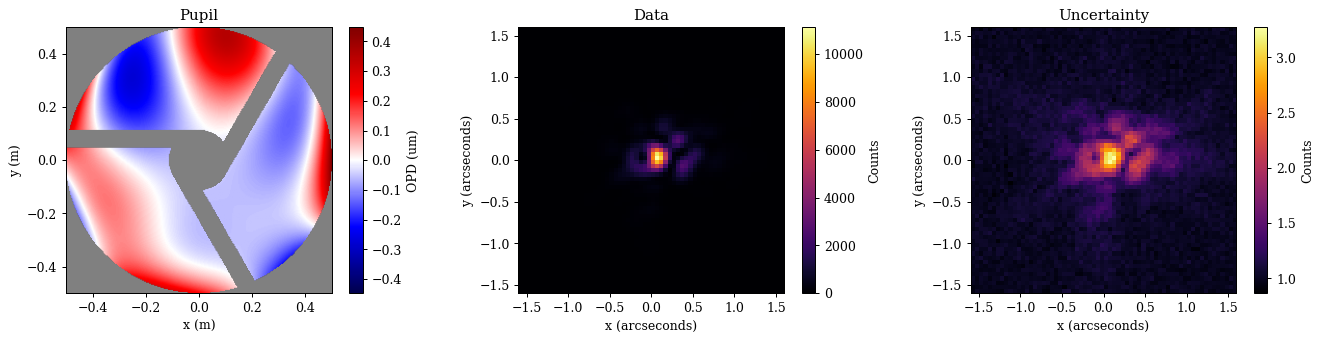

In [7]:
## COLLAPSE: Plotting
# Get the aperture and OPD for visualisation
opd = 1e6 * optics.aberrations.eval_basis() # Normalise to microns
pupil = opd.at[optics.transmission < 0.5].set(np.nan)

# Get the extents for visualisation
ap_extent = dlu.imshow_extent(optics.diameter)
psf_extent = dlu.imshow_extent(optics.fov)

# Plot the results
plt.figure(figsize=(15, 3.75))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(pupil, seismic, norm=CenteredNorm(), extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="Pupil", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 3, 2)
im = ax.imshow(data, inferno, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Data", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

ax = plt.subplot(1, 3, 3)
im = ax.imshow(error ** 0.5, inferno, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Uncertainty", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

plt.tight_layout()
plt.show()

---

## 3. A Basic Optimisation Workflow

Okay this looks good! Now lets see how we can use our model and this data to recover the stellar position and flux, while also recovering the optical aberrations! To do this, we first need to set our define our likelihood function and set the initial values of our model. For our likelihood function we will use the z-score, which is a standardised measure of the difference between our model and the data. Lets see how to do that quickly.

In [8]:
def predict_data(params, optics):
    """Predict the data given the current parameters and model"""
    # Unpack and cast the parameters to the correct units
    flux = 10 ** params["flux"]
    position = dlu.arcsec2rad(params["position"])

    # Update the optical system with the current parameters
    optics = optics.set(coefficients=params["z-coeffs"])

    # Predict the PSF
    return flux * optics.propagate(wavels, position, weights=weights)


@eqx.filter_jit
@eqx.filter_value_and_grad
def loss_fn(params, optics, data, error):
    """Basic loss function"""
    psf = predict_data(params, optics)
    return np.square(zdx.z_score(psf, data, error)).mean()

Great now lets do some optimisation. Here we need to use use a staged optimisation strategy to make sure we recover our parameters correctly, as well as tune the learning rates for each parameter. This is simply the most direct approach, but there are lots of other ways to tackle this problem! For a more complete tutorial on optimisation within the zodiax framework, check out [this tutorial](https://louisdesdoigts.github.io/zodiax/optimisation_tools/). For now, we are going to assume that you have been through that tutorial (although don't worry if you haven't, its all very straight forwards and you should be able to follow without any trouble). Lets see how to set up this likelihood function and optimisation in practice.

In [9]:
# Set up the initial parameters
params = {
    "z-coeffs": np.zeros_like(coeffs),
    "flux": np.log10(data.sum()),
    "position": np.zeros(2),
}

# Set up the optimisers for each parameter
# Note we use the delay function to delay the optimisation of certain parameters
optimisers = {
    "position": optax.sgd(zdx.delay(5e-8, 0), momentum=0.5),
    "z-coeffs": optax.sgd(zdx.delay(2e-1, 25), momentum=0.5),
    "flux": optax.sgd(zdx.delay(1e-6, 50), momentum=0.5),
}
optim, state = zdx.map_optimisers(params, optimisers)

# Now we can run a simple optimisation loop
epochs = 100
pbar = tqdm(range(epochs))
losses, params_history = [], []
for step in pbar:
    loss, grads = loss_fn(params, optics, data, error)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    pbar.set_postfix(log_loss=f"{np.log10(loss):.4f}")
    losses.append(loss)
    params_history.append(params)
losses = np.array(losses)

  0%|          | 0/100 [00:00<?, ?it/s]

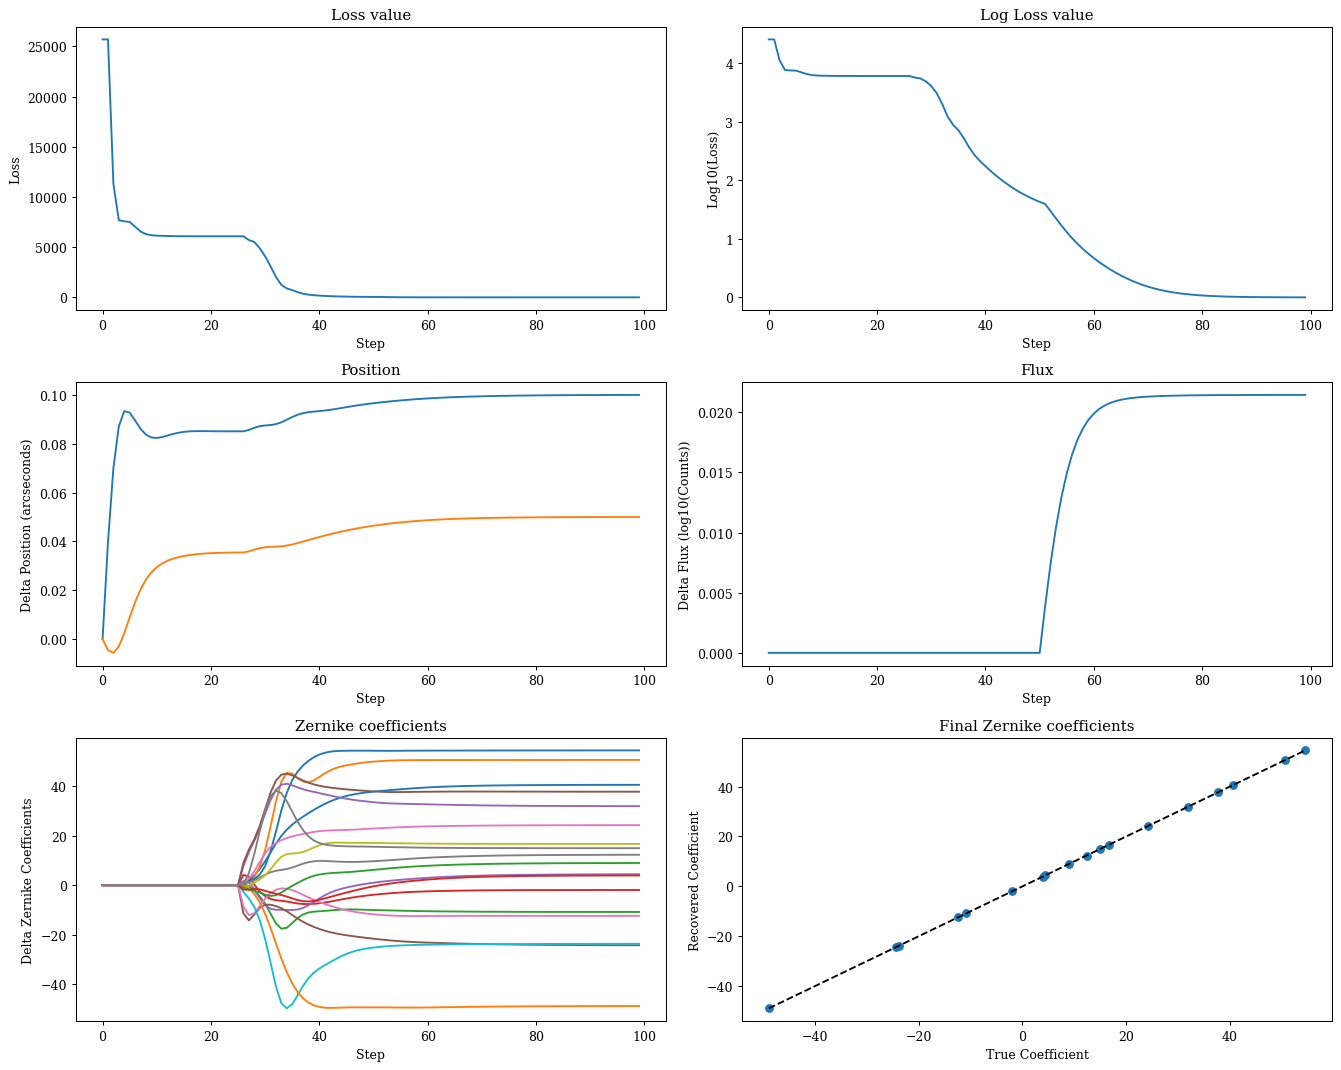

In [10]:
## COLLAPSE: Plotting
# Map the parameter history to arrays for plotting
values = {}
for param in params.keys():
    value = np.array([params[param] for params in params_history])
    values[param] = (value - value[0]).reshape(epochs, -1)

# Plot the losses
plt.figure(figsize=(15, 12))
ax = plt.subplot(3, 2, 1)
ax.plot(losses)
ax.set(title="Loss value", xlabel="Step", ylabel="Loss")

ax = plt.subplot(3, 2, 2)
ax.plot(np.log10(losses))
ax.set(title="Log Loss value", xlabel="Step", ylabel="Log10(Loss)")

ax = plt.subplot(3, 2, 3)
ax.plot(values["position"])
ax.set(title="Position", xlabel="Step", ylabel="Delta Position (arcseconds)")

ax = plt.subplot(3, 2, 4)
ax.plot(values["flux"])
ax.set(title="Flux", xlabel="Step", ylabel="Delta Flux (log10(Counts))")

ax = plt.subplot(3, 2, 5)
ax.plot(values["z-coeffs"])
ax.set(title="Zernike coefficients", xlabel="Step", ylabel="Delta Zernike Coefficients")

ax = plt.subplot(3, 2, 6)
ax.scatter(coeffs, values["z-coeffs"][-1])
ax.plot([coeffs.min(), coeffs.max()], [coeffs.min(), coeffs.max()], "k--", label="1:1")
ax.set(title="Final Zernike coefficients", ylabel="Recovered Coefficient", xlabel="True Coefficient")

plt.tight_layout()
plt.show()

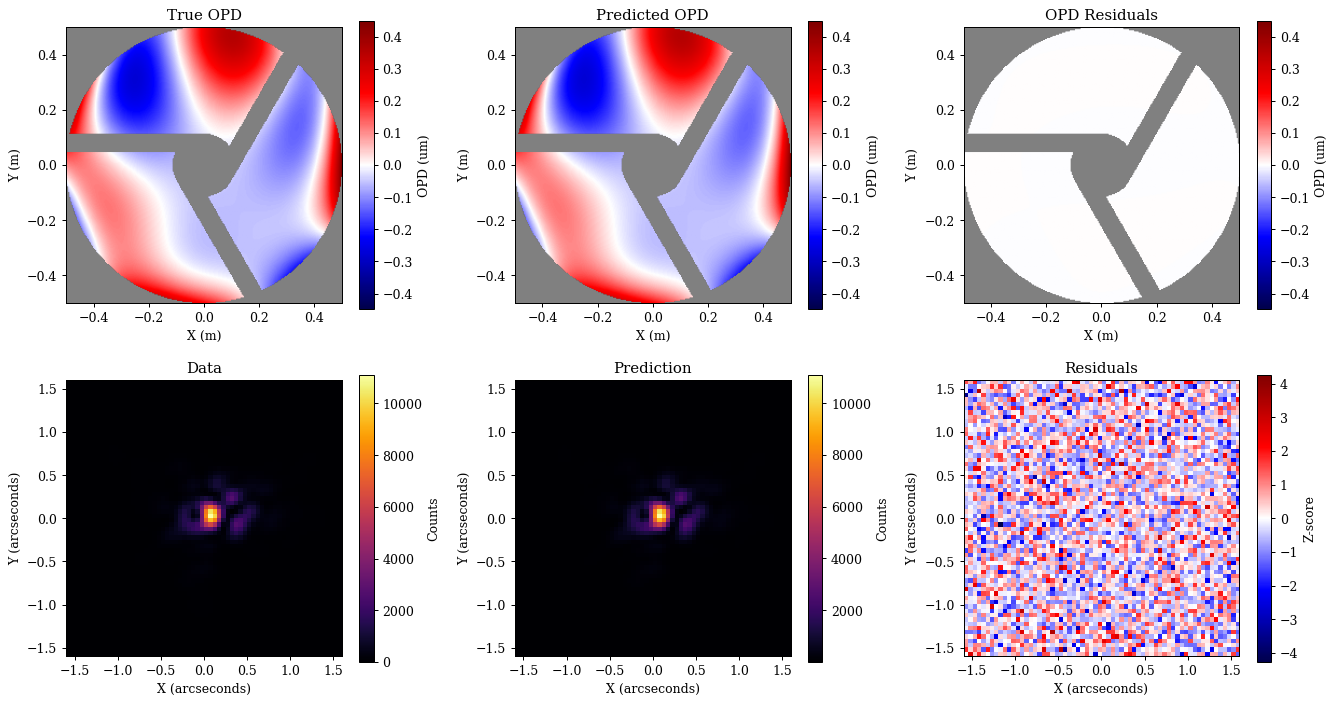

In [11]:
## COLLAPSE: Plotting
# Get the aperture and OPD for visualisation
pred_opd = 1e6 * optics.set(coefficients=params["z-coeffs"]).aberrations.eval_basis()
pred_pupil = pred_opd.at[optics.transmission < 0.5].set(np.nan)
pupil_residuals = pred_pupil - pupil
v = np.nanmax(np.abs(np.array([pupil, pred_pupil])))

# Get our predicted data for the final parameters
pred = predict_data(params, optics)
z_score = zdx.z_score(pred, data, error)

plt.figure(figsize=(15, 8))
ax = plt.subplot(2, 3, 1)
im = ax.imshow(pupil, seismic, vmin=-v, vmax=v, extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="True OPD", xlabel="X (m)", ylabel="Y (m)")

ax = plt.subplot(2, 3, 2)
im = ax.imshow(pred_pupil, seismic, vmin=-v, vmax=v, extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="Predicted OPD", xlabel="X (m)", ylabel="Y (m)")

ax = plt.subplot(2, 3, 3)
im = ax.imshow(pupil_residuals, seismic, vmin=-v, vmax=v, extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="OPD Residuals", xlabel="X (m)", ylabel="Y (m)")

ax = plt.subplot(2, 3, 4)
im = ax.imshow(data, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Data", xlabel="X (arcseconds)", ylabel="Y (arcseconds)")

ax = plt.subplot(2, 3, 5)
im = ax.imshow(pred, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Prediction", xlabel="X (arcseconds)", ylabel="Y (arcseconds)")

ax = plt.subplot(2, 3, 6)
im = ax.imshow(z_score, seismic, norm=CenteredNorm(), extent=psf_extent)
plt.colorbar(im, ax=ax, label="Z-score")
ax.set(title="Residuals", xlabel="X (arcseconds)", ylabel="Y (arcseconds)")

plt.tight_layout()
plt.show()

Great, as we can see we have correctly recovered all of our parameters, and there is no more information to extract from the data! This is a good sign that our model is correct and that we have done everything right. Now lets turn to a more complex example including detector effects with a much higher dimensionality.

---

## 4. Instrumental Calibration

Great, that was all pretty straight forwards! Now lets move onto a more complex example where we solve for more that just wavefront error. We will follow a more real-world example here, using an intentionally defocused and dithered PSF to solve the individual pixel sensitivities of the detector, while also recovering the flux and wavefront error of the system. This will show us how we can set up more complex observing scenarios, as well as solve high-dimensional problems with dLux and zodiax.

To do this we need to create a dLux detector object, which functionally operate in the same way as the optical system - we define a series of layers that operate sequentially on the image, as opposed to the wavefront. For this example we will include two layers, a jitter layer to represent the jitter of the telescope, and a pixel response function (PRF) layer to represent the pixel sensitivities of the detector. Lets look at how to do this now. 

In [12]:
# Build our detector with jitter and a random flat field
detector = dl.LayeredDetector(
    layers=[
        ("jitter", dl.ApplyJitter(sigma=1, kernel_size=9, oversample=3)),
        ("prf", dl.ApplyPixelResponse(1 + 0.05 * jr.normal(jr.key(0), psf.shape))),
    ]
)

# Examine the detector object
print(detector)

LayeredDetector(
  layers={
    'jitter': ApplyJitter(sigma=1.0, kernel_size=9, oversample=3),
    'prf': ApplyPixelResponse(pixel_response=f32[64,64])
  }
)


As we can see our detector object looks very similar to our optical system object, parametrised by a series of sequential layers. Lets take a quick look at the jitter kernel and the pixel response function to see what they look like.

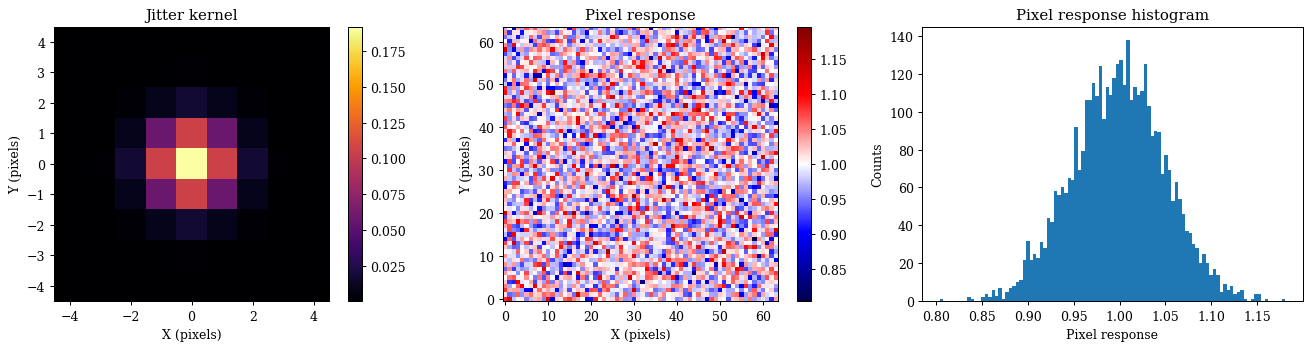

In [13]:
## COLLAPSE: Plotting
kern = detector.jitter.kernel
prf = detector.prf.pixel_response
c = kern.shape[0] / 2
kern_ext = (-c, c, -c, c)

plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(kern, extent=kern_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Jitter kernel", xlabel="X (pixels)", ylabel="Y (pixels)")

ax = plt.subplot(1, 3, 2)
im = ax.imshow(prf, seismic, norm=CenteredNorm(vcenter=1))
plt.colorbar(im, ax=ax)
ax.set(title="Pixel response", xlabel="X (pixels)", ylabel="Y (pixels)")

ax = plt.subplot(1, 3, 3)
ax.hist(prf.flatten(), bins=100)
ax.set(title="Pixel response histogram", xlabel="Pixel response", ylabel="Counts")

plt.tight_layout()
plt.show()

Okay great, now that we have the detector set up lets see how we can intentionally defocus our instrument in order to get a PSF better suited to calibrate the pixel sensitivities. To do this we will look at how to create a custom layer. This is one of the core tenets of the way dLux is constructed, its designed to be flexible and extensible, enabbling users to add any arbitrary transformation to the wavefront or PSF that is needed to represent any real-world system. Lets have a look at how to make a custom optical layer.

To create a custom optical layer, we simply need to inherit from the `OpticalLayer` class and define a `__call__` method that takes in a wavefront, applies the transformation, and then returns it - thats all! This means that we can parametrise and customise this layer however we want! For our defocus layer we will compute the zernike defocus term, normalise it to a peak-to-valley of 1, and parametrise the amplitude of the defocus by the 'number of waves' or `n_waves` of defocus we apply to a specific target wavelength. We can also create some nice helper functions or visualisation tools into the class to make it easier to understand and work with. Here we will add a `lens` property in order to generate the lens OPD when we want to look at it.

After we have defined the `WeakLens` layer, we can insert it into our optical system and see how it behaves! We are also going to reduce the amount of optical aberrations within the system to make it easier to see the effect of the defocus, besides, we already did phase retrieval in the last section so we already know what they are and can correct for them!

In [14]:
# Define our custom weak lens layer
class WeakLens(dl.OpticalLayer):
    """A simple weak lens layer for testing"""
    defocus: np.ndarray
    n_waves: float
    target_wl: float

    def __init__(self, npixels, target_wl, n_waves=1):
        # Set the target wavelength and number of waves of defocus
        self.target_wl = float(target_wl)
        self.n_waves = float(n_waves)

        # Generate the lens defocus, normalise the peak to valley to be 1
        defocus = dlu.zernike(4, dlu.pixel_coords(npixels, 1), 1)
        defocus /= (defocus.max() - defocus.min())
        self.defocus = defocus

    @property
    def lens(self):
        """Gets the lens OPD in meters"""
        return self.defocus * self.n_waves * self.target_wl

    def __call__(self, wavefront):
        """Applies the lens to the wavefront"""
        return wavefront.add_opd(self.lens)

# Construct our weak lens
weak_lens = WeakLens(wf_npix, wavels.mean(), n_waves=1)

# Insert the weak lens into our optical system
optics = optics.insert_layer(("weak_lens", weak_lens), 2)

# Reduce the aberrations to make it easier to see the effect of the weak lens
optics = optics.multiply(coefficients=0.1)

# Examine the optics with the weak lens
print(optics)

AngularOpticalSystem(
  wf_npixels=256,
  diameter=1.0,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[256,256], normalise=True),
    'aberrations':
    BasisLayer(basis=f32[18,256,256], coefficients=f32[18], as_phase=False),
    'weak_lens':
    WeakLens(defocus=f32[256,256], n_waves=1.0, target_wl=8.750000120016921e-07)
  },
  psf_npixels=64,
  oversample=1,
  psf_pixel_scale=0.05
)


Great, as we can see we now have our new defocusing lens layer in our optical system. Lets take a look at what happens to our PSF when we add different amount of defocus to the system. This is a good way to check that our layer is doing what we expect it to be doing, and that we are applying the correct amount of defocus to the system.

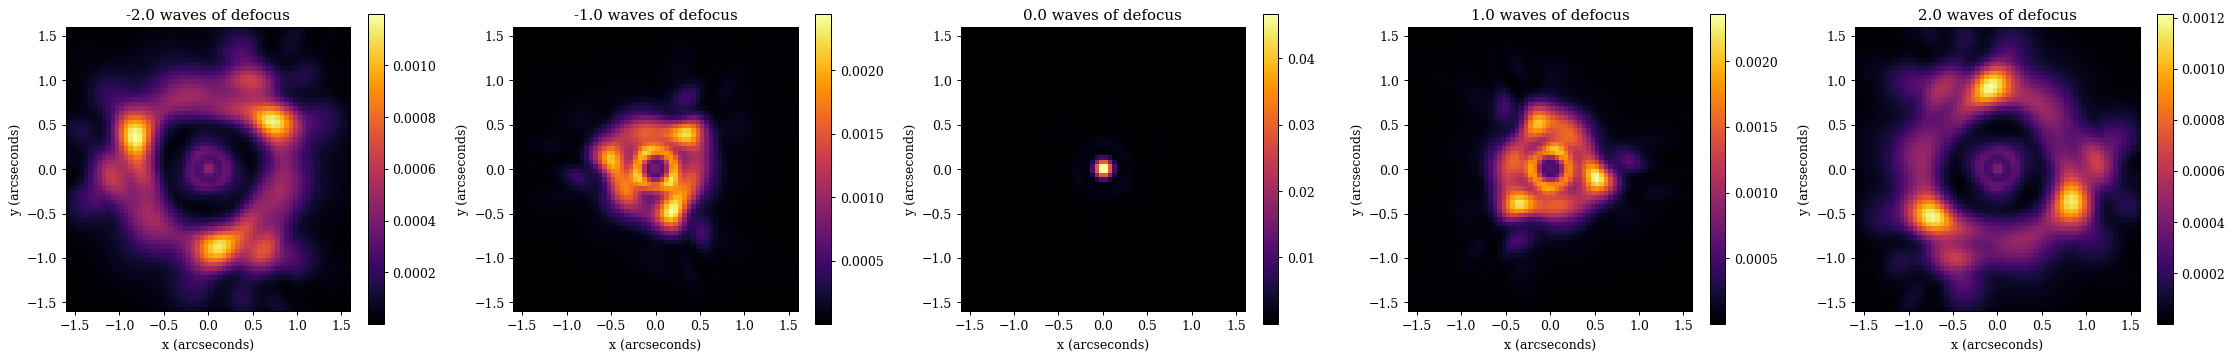

In [15]:
## COLLAPSE: Plotting
waves = np.linspace(-2, 2, 5)

plt.figure(figsize=(25, 4))
for i in range(len(waves)):
    psf = optics.set(n_waves=waves[i]).propagate(wavels)

    ax = plt.subplot(1, 5, i + 1)
    im = ax.imshow(psf, extent=psf_extent)
    plt.colorbar(im, ax=ax)
    ax.set(title=f"{waves[i]:.1f} waves of defocus", xlabel="x (arcseconds)", ylabel="y (arcseconds)")
plt.tight_layout()
plt.show()

That looks pretty good! As we increase the amount of defocus, we get a larger PSF. Here we can also see the effect of the asymmetric aperture of the Euclid telescope - the positively and negatively defocused PSFs look different! This is why we have chosen this optical system for our example, as this aperture makes it much easier to recover the even-mode Zernike terms that suffer from a sign degeneracy when using a symmetric aperture. 

Now we want to choose a PSF that is ideal for calibrating the pixel sensitivities of our detector, so we want to choose a defocus value that gives as nicely spread out PSF that is roughly uniformly spread out across a large number of pixels. In this case we can clearly see that the PSF with 1 wave of defocus is the best for this, so we will use that for the rest of the example. We can also see that we should be able to cover most of the pixel in the detector by using an 9 point dither pattern, placing the PSF at the center of each box of a 3x3 grid across the detector.

In [16]:
class DitherModel(zdx.Base):
    """Models multiple dithered PSFs"""
    dithers: np.ndarray
    wavels: np.ndarray
    weights: np.ndarray
    optics: dl.AngularOpticalSystem
    detector: dl.LayeredDetector

    def __init__(self, optics, detector, dithers, wavels, weights):
        self.optics = optics
        self.detector = detector
        self.dithers = np.array(dithers, float)
        self.wavels = np.array(wavels, float)
        self.weights = np.array(weights, float)

    def update_optics(self, params):
        """Updates the optics with the current parameters"""
        if "z-coeffs" in params:
            return self.optics.set(coefficients=params["z-coeffs"])
        return self.optics

    def update_detector(self, params):
        """Updates the detector with the current parameters"""
        detector = self.detector
        if "jitter" in params and "prf" in params:
            detector = detector.set(sigma=params["jitter"])
        if "prf" in params:
            detector = detector.set(pixel_response=params["prf"])
        return detector

    def __call__(self, params):
        """Models the data given the current parameters and model"""
        optics = self.update_optics(params)
        detector = self.update_detector(params)

        # Get the positions and apply the flux via the weights
        positions = dlu.arcsec2rad(params["position"][None] + self.dithers)
        weights = 10 ** params["flux"] * self.weights

        # Define the modelling function and propagate the dithers
        model_fn = lambda pos: detector(
            optics.propagate(self.wavels, pos, weights, return_psf=True)
        )
        return eqx.filter_vmap(model_fn)(positions)

    def simulate(self, params, n_frames=100, key=jr.key(0), read_noise=10.0):
        """Simulates a number of frames of data given the current parameters and model"""
        # Predict the illuminance for the input parameters
        illuminance = self(params)

        # Draw the photons and read noise from the appropriate distributions
        keys = jr.split(key, 2)
        shape = (n_frames, *illuminance.shape)

        # Draw the photons and read noise from the appropriate distributions
        photons = jr.poisson(keys[0], illuminance, shape)
        read_electrons = read_noise * jr.normal(keys[1], shape)

        # Create the data by defining the image as the sum of the photons and the read noise
        images = photons + read_electrons
        data = images.mean(0)
        error = images.std(0) / np.sqrt(n_frames)

        # Return the data and the error
        return data, error

# Define our dithers - a 3x3 grid of dithers across the field of view
grid = np.arange(-2, 3) * optics.fov / 6
dithers = np.array(np.meshgrid(grid, grid[::-1])).reshape(2, -1).T
dither_model = DitherModel(optics, detector, dithers, wavels, weights)

# Examine the dither model
print(dither_model)

DitherModel(
  dithers=f32[25,2],
  wavels=f32[5],
  weights=f32[5],
  optics=AngularOpticalSystem(
    wf_npixels=256,
    diameter=1.0,
    layers={
      'aperture': TransmissiveLayer(transmission=f32[256,256], normalise=True),
      'aberrations':
      BasisLayer(basis=f32[18,256,256], coefficients=f32[18], as_phase=False),
      'weak_lens':
      WeakLens(
        defocus=f32[256,256], n_waves=1.0, target_wl=8.750000120016921e-07
      )
    },
    psf_npixels=64,
    oversample=1,
    psf_pixel_scale=0.05
  ),
  detector=LayeredDetector(
    layers={
      'jitter': ApplyJitter(sigma=1.0, kernel_size=9, oversample=3),
      'prf': ApplyPixelResponse(pixel_response=f32[64,64])
    }
  )
)


As we can see, we now have an object that hold both our optical system, our detector, as well as the parameters of our dithering pattern. Ultimately, there an infinite number of ways we could set up this problem, this is just one example of one way to do it, but the flexibility of dLux means that you can set up the problem in whatever way makes the most sense to you and your instrument! Now that we have this object, we can use it to simulate some data and have a look at it to see what we are working with.

In [17]:
# Simulate some data using our dither model
true_params = {"flux": 6.0, "position": np.array([0.01, -0.02])}
data, error = dither_model.simulate(true_params, n_frames=50)

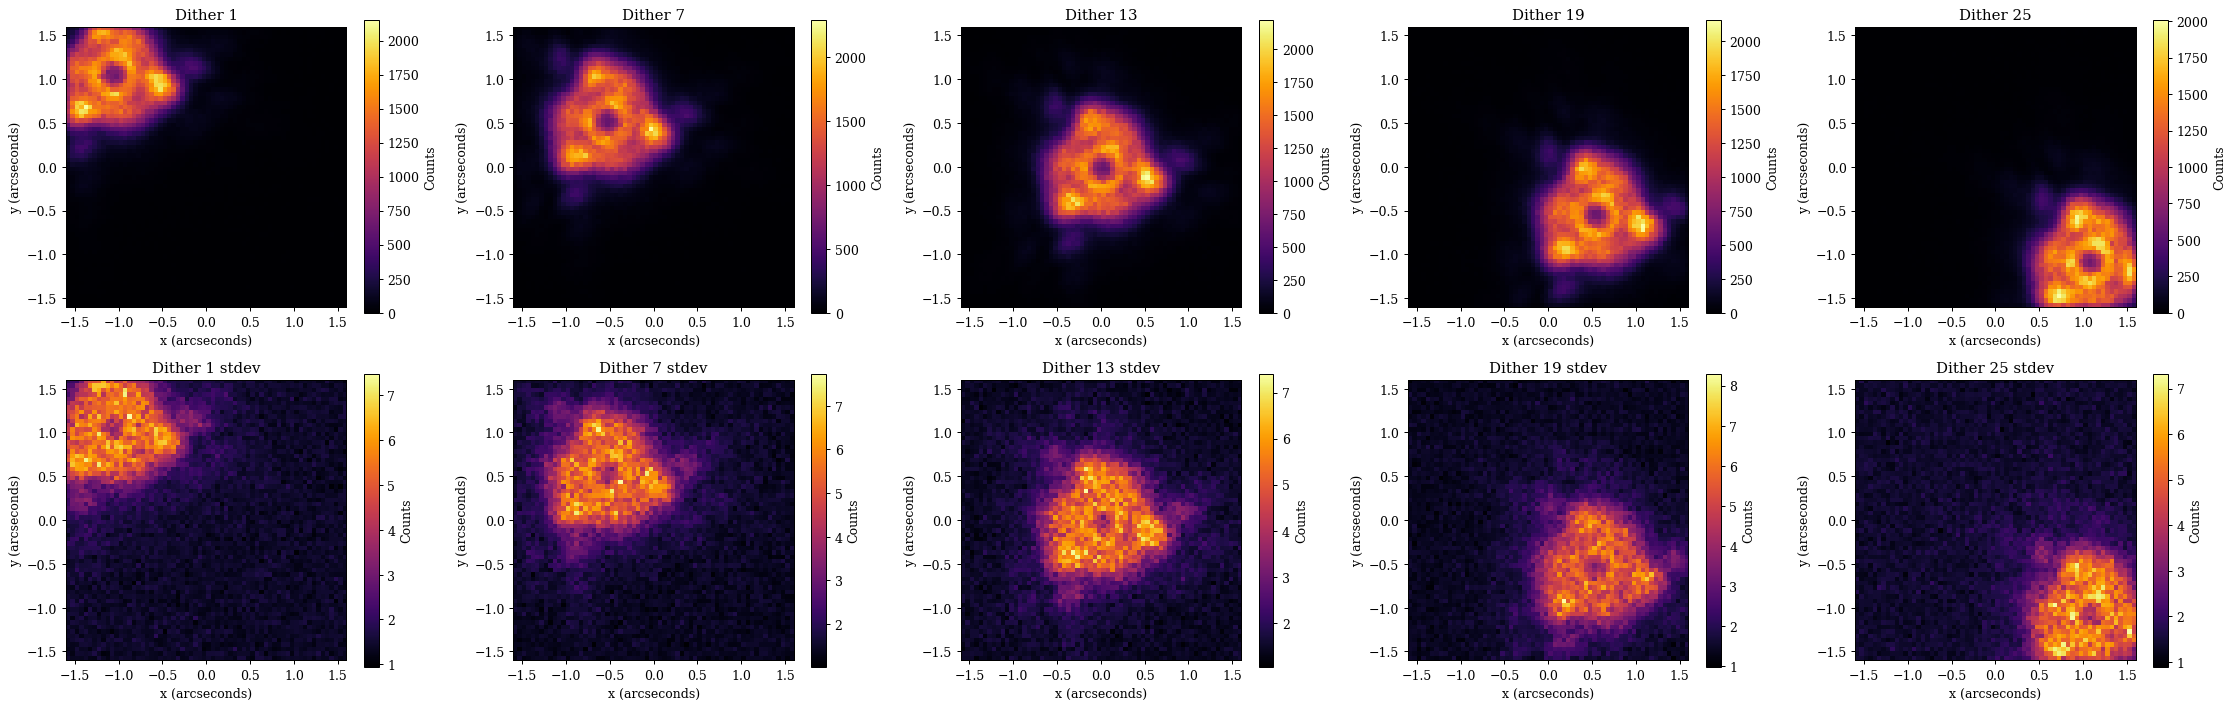

In [18]:
## COLLAPSE: Plotting
dithers_inds = np.round(np.linspace(0, len(dithers)-1, 5), decimals=0).astype(int)

plt.figure(figsize=(25, 8))
for i in range(len(dithers_inds)):
    d = dithers_inds[i]
    ax = plt.subplot(2, 5, i+1)
    im = ax.imshow(data[d], extent=psf_extent)
    ax.set(title=f"Dither {d+1}", xlabel="x (arcseconds)", ylabel="y (arcseconds)")
    plt.colorbar(im, ax=ax, label="Counts")

for i in range(len(dithers_inds)):
    d = dithers_inds[i]
    ax = plt.subplot(2, 5, i + 6)
    im = ax.imshow(error[d], extent=psf_extent)
    ax.set(title=f"Dither {d+1} stdev", xlabel="x (arcseconds)", ylabel="y (arcseconds)")
    plt.colorbar(im, ax=ax, label="Counts")

plt.tight_layout()
plt.show()

Okay that all looks great, we can already see the noise introduced by the individual pixel sensitivities. Now lets use this data to calibrate the pixel sensitivities of the detector, while also recovering all of the rest of the parameters of the system! The set up for this is basically identical to the optimisation we did in the last section, we just have more parameters to solve for.

In [19]:
@eqx.filter_jit
@eqx.filter_value_and_grad
def loss_fn(params, dither_model, data, error):
    """Basic loss function"""
    psf = dither_model(params)
    return np.square(zdx.z_score(psf, data, error)).mean()

# Set up the initial parameters
params = {
    "flux": np.log10(data.mean(0).sum()),
    "position": np.zeros(2),
    "z-coeffs": np.zeros_like(coeffs),
    "jitter": np.array(0.5),
    "prf": np.ones(detector.pixel_response.shape),
}

# Set up the optimisers for each parameter
optimisers = {
    "position": optax.sgd(zdx.delay(1e-6, 0), momentum=0.5),
    "z-coeffs": optax.sgd(zdx.delay(1e-1, 25), momentum=0.5),
    "flux": optax.sgd(zdx.delay(1e-6, 50), momentum=0.5),
    "jitter": optax.sgd(zdx.delay(5e-4, 75), momentum=0.5),
    "prf": optax.adam(zdx.delay(2e-2, 100)),
}
optim, state = zdx.map_optimisers(params, optimisers)

# Now we can run a simple optimisation loop
epochs = 250
pbar = tqdm(range(epochs))
losses, params_history = [], []
for step in pbar:
    loss, grads = loss_fn(params, dither_model, data, error)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    pbar.set_postfix(log_loss=f"{np.log10(loss):.4f}")

    # Normalise the PRF to have a mean of 1 to avoid degeneracies with flux
    params["prf"] -= (np.median(params["prf"]) - 1)
    losses.append(loss)
    params_history.append(params)
losses = np.array(losses)

  0%|          | 0/250 [00:00<?, ?it/s]

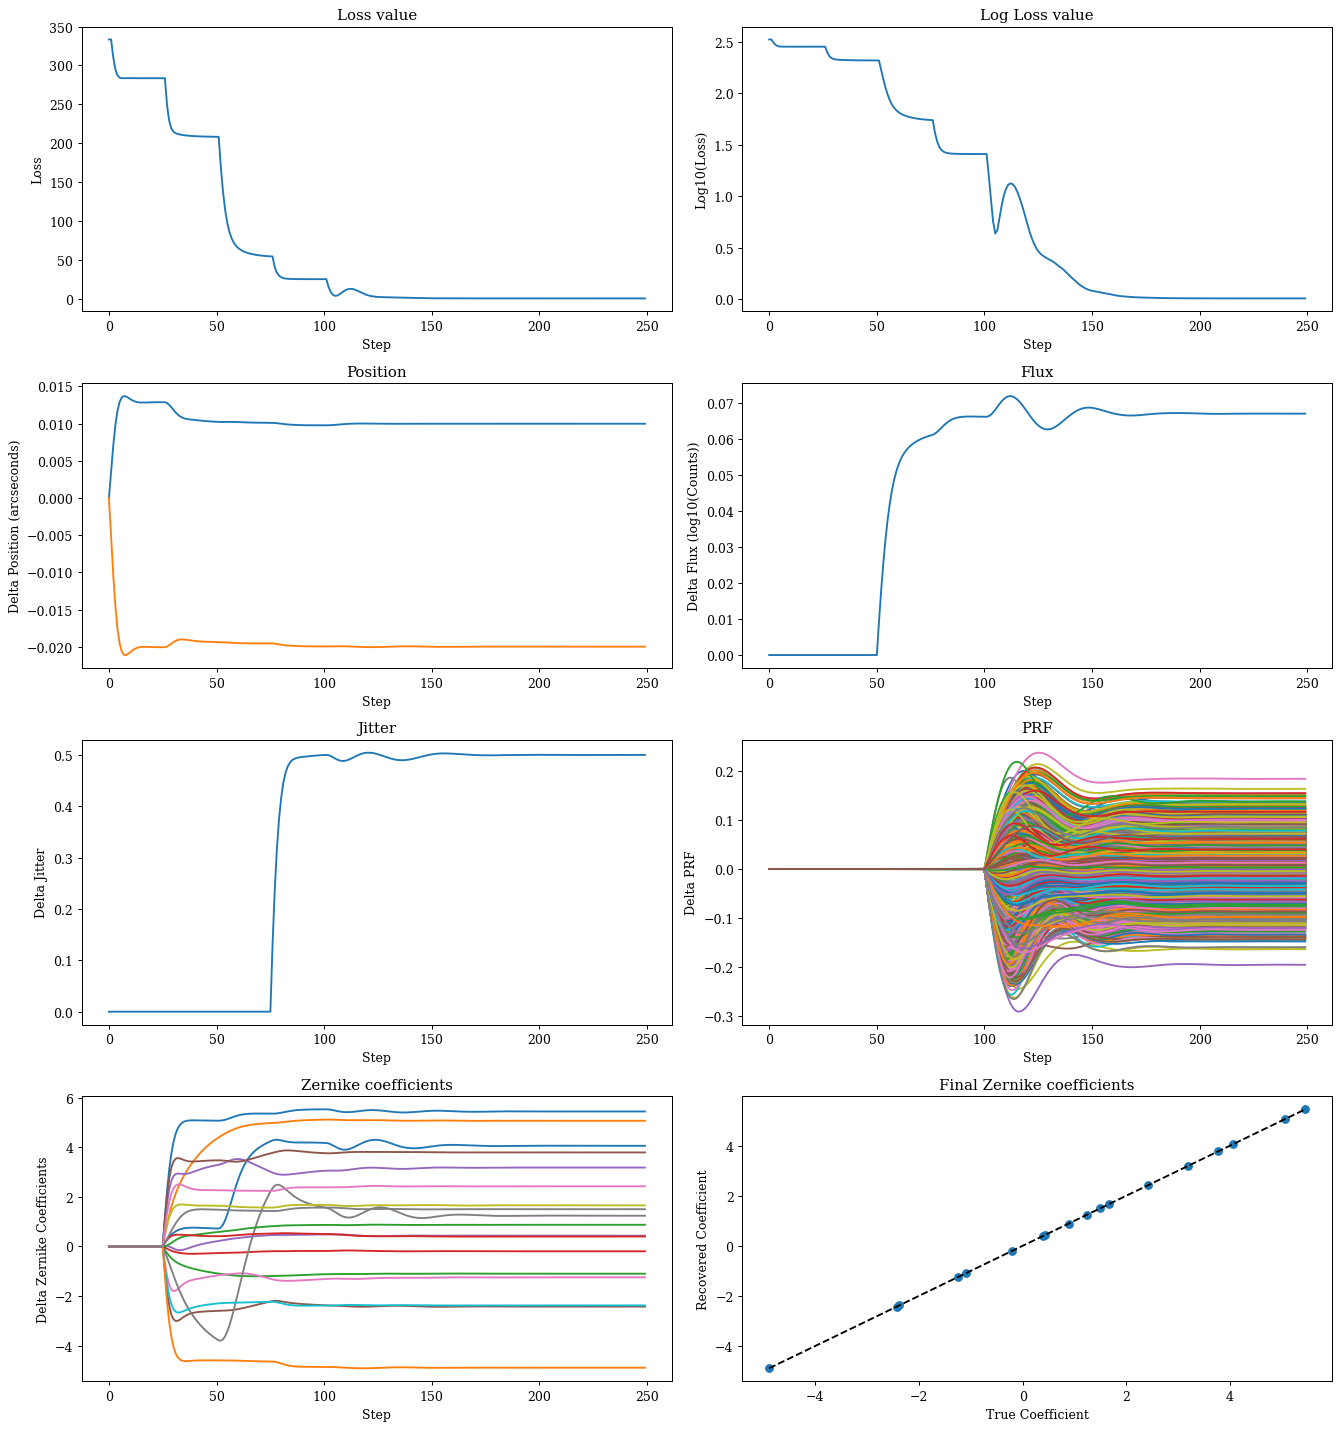

In [20]:
## COLLAPSE: Plotting
# Map the parameter history to arrays for plotting
values = {}
for param in params.keys():
    value = np.array([params[param] for params in params_history])
    values[param] = (value - value[0]).reshape(epochs, -1)

# Plot the losses
plt.figure(figsize=(15, 16))
ax = plt.subplot(4, 2, 1)
ax.plot(losses)
ax.set(title="Loss value", xlabel="Step", ylabel="Loss")

ax = plt.subplot(4, 2, 2)
ax.plot(np.log10(losses))
ax.set(title="Log Loss value", xlabel="Step", ylabel="Log10(Loss)")

ax = plt.subplot(4, 2, 3)
ax.plot(values["position"])
ax.set(title="Position", xlabel="Step", ylabel="Delta Position (arcseconds)")

ax = plt.subplot(4, 2, 4)
ax.plot(values["flux"])
ax.set(title="Flux", xlabel="Step", ylabel="Delta Flux (log10(Counts))")

ax = plt.subplot(4, 2, 5)
ax.plot(values["jitter"])
ax.set(title="Jitter", xlabel="Step", ylabel="Delta Jitter")

ax = plt.subplot(4, 2, 6)
ax.plot(values["prf"])
ax.set(title="PRF", xlabel="Step", ylabel="Delta PRF")

ax = plt.subplot(4, 2, 7)
ax.plot(values["z-coeffs"])
ax.set(title="Zernike coefficients", xlabel="Step", ylabel="Delta Zernike Coefficients")

_coeffs = optics.coefficients
ax = plt.subplot(4, 2, 8)
ax.scatter(_coeffs, values["z-coeffs"][-1])
ax.plot([_coeffs.min(), _coeffs.max()], [_coeffs.min(), _coeffs.max()], "k--", label="1:1")
ax.set(
    title="Final Zernike coefficients",
    ylabel="Recovered Coefficient",
    xlabel="True Coefficient",
)

plt.tight_layout()
plt.show()

Now lets take a quick look at the fits of some our different dithers

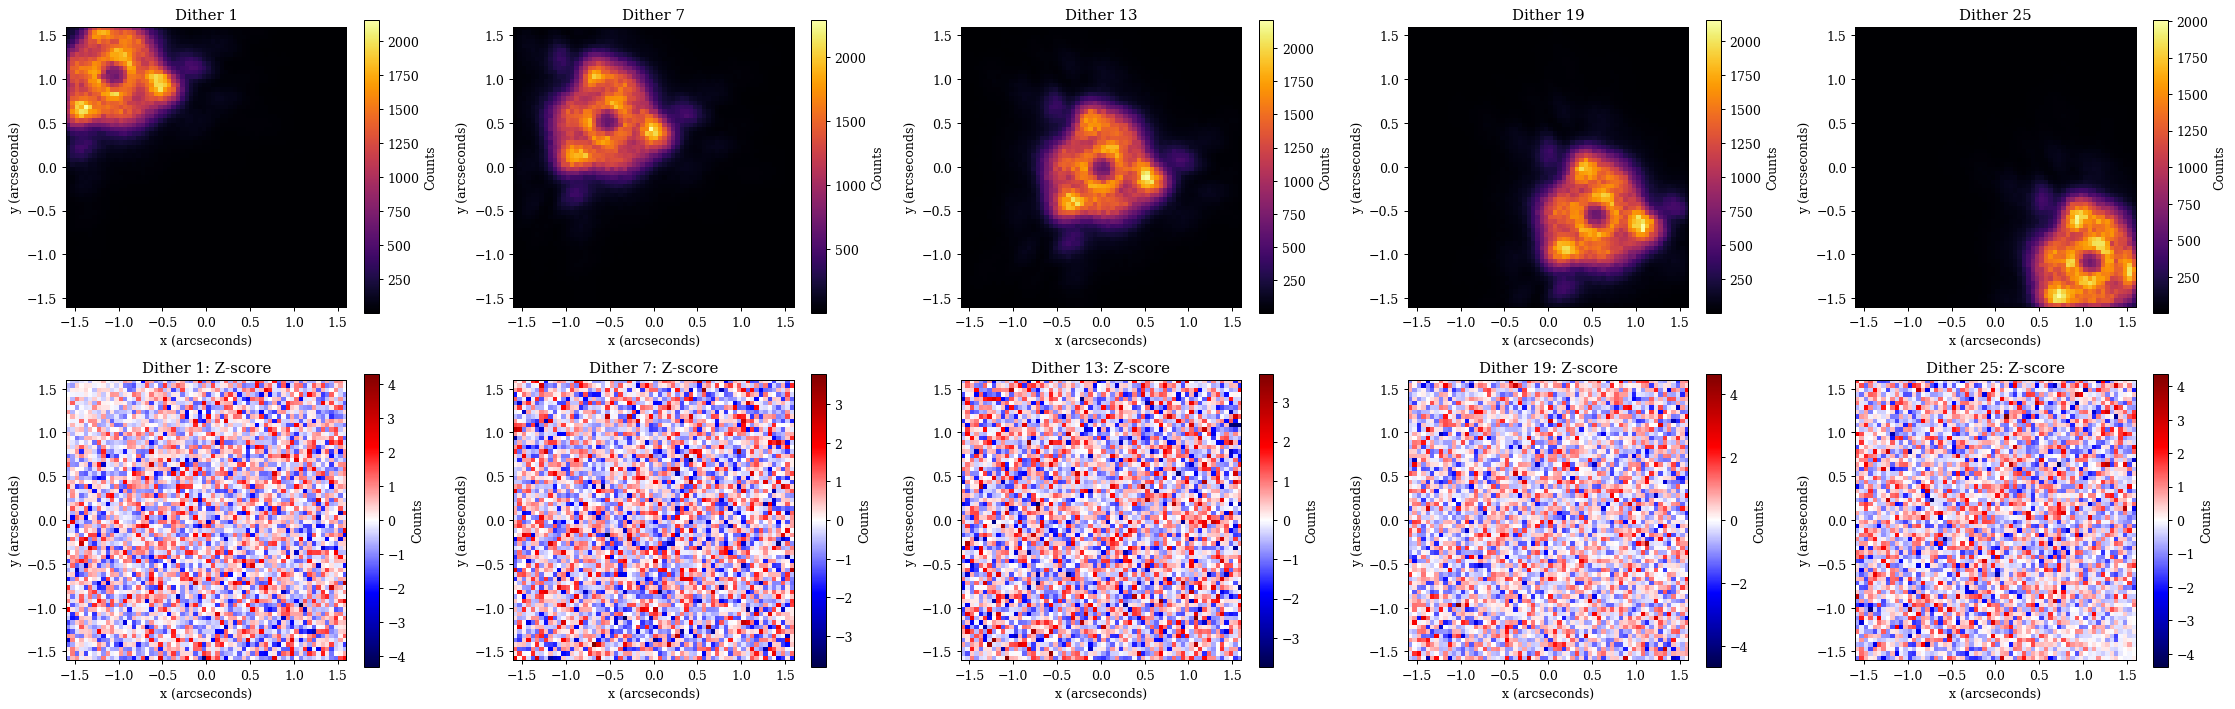

In [21]:
## COLLAPSE: Plotting
pred = dither_model(params)
z_scores = zdx.z_score(pred, data, error)

plt.figure(figsize=(25, 8))
for i in range(len(dithers_inds)):
    d = dithers_inds[i]
    ax = plt.subplot(2, 5, i + 1)
    im = ax.imshow(pred[d], extent=psf_extent)
    ax.set(title=f"Dither {d+1}", xlabel="x (arcseconds)", ylabel="y (arcseconds)")
    plt.colorbar(im, ax=ax, label="Counts")

for i in range(len(dithers_inds)):
    d = dithers_inds[i]
    ax = plt.subplot(2, 5, i + 6)
    im = ax.imshow(z_scores[d], "seismic", extent=psf_extent, norm=CenteredNorm())
    ax.set(title=f"Dither {d+1}: Z-score", xlabel="x (arcseconds)", ylabel="y (arcseconds)")
    plt.colorbar(im, ax=ax, label="Counts")

plt.tight_layout()
plt.show()

Awesome everyhting looks good, now lets take a look at our recovered pixel response function

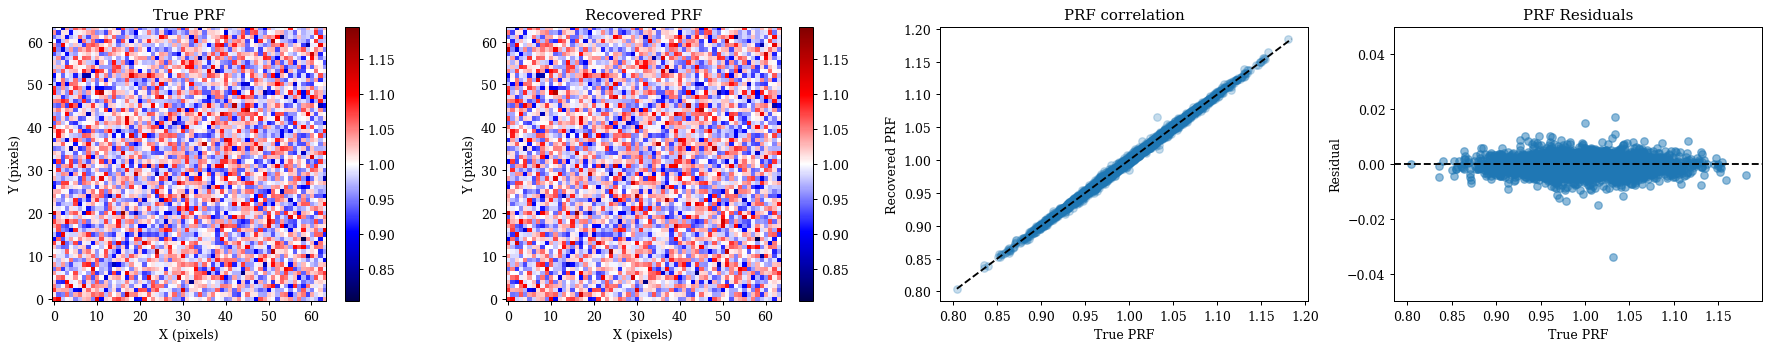

In [22]:
## COLLAPSE: Plotting
true_prf = detector.pixel_response
recovered_prf = params["prf"]

plt.figure(figsize=(20, 4))
ax = plt.subplot(1, 4, 1)
im = ax.imshow(true_prf, seismic, norm=CenteredNorm(vcenter=1))
ax.set(title="True PRF", xlabel="X (pixels)", ylabel="Y (pixels)")
plt.colorbar(im, ax=ax)

ax = plt.subplot(1, 4, 2)
im = ax.imshow(recovered_prf, seismic, norm=CenteredNorm(vcenter=1))
ax.set(title="Recovered PRF", xlabel="X (pixels)", ylabel="Y (pixels)")
plt.colorbar(im, ax=ax)

prfs = np.array([true_prf, recovered_prf])
ax = plt.subplot(1, 4, 3)
plt.scatter(true_prf.flatten(), recovered_prf.flatten(), alpha=0.25)
ax.plot([prfs.min(), prfs.max()], [prfs.min(), prfs.max()], "k--", label="1:1")
ax.set(title="PRF correlation", xlabel="True PRF", ylabel="Recovered PRF")

ax = plt.subplot(1, 4, 4)
plt.scatter(true_prf.flatten(), true_prf.flatten() - recovered_prf.flatten(), alpha=0.5)
ax.set(title="PRF Residuals", xlabel="True PRF", ylabel="Residual", ylim=(-0.05, 0.05))
ax.axhline(0, color="k", ls="--")

plt.tight_layout()
plt.show()